# H5 – Einfluss von Lag-Features

|                       |                                                                                                                         |
|-----------------------|-------------------------------------------------------------------------------------------------------------------------|
| **Hypothese**         | Die Ergänzung eines 24h-Lag-Features verbessert die Prognose des Random Forest gegenüber dem reinen Zeitfeature-Modell. |
| **Typ**               | Unterschiedshypothese / gerichtet                                                                                       |
| **H₀**                | MAE(RF TIME+LAG) ≥ MAE(RF TIME)                                                                                         |
| **H₁**                | MAE(RF TIME+LAG) < MAE(RF TIME)                                                                                         |
| **Testverfahren**     | Paired t-Test (einseitig) auf per-Zeitschritt absolute Fehler                                                           |
| **Signifikanzniveau** | α = 0.05                                                                                                                |

**Modelle:**
- **RF TIME:** `ghi_cloudy_sky`, `clear_sky_index`, `temperature_2m`, `cloud_cover_low`, `interval_cos_shifted`, `month_cos_shifted`, `doy_cos_shifted`
- **RF TIME+LAG:** dieselben Features + `Solarproduktion_lag_96` (Produktion des Vortags-Slots, 24h-Rückblick)

## 0 · Setup

In [1]:
import sys
sys.path.insert(0, '../..')

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats

from src.evaluation.results import load_predictions

ALPHA  = 0.05
P_NOM  = 13_500.0

RESULTS_RF = Path('../../results/02_random_forest')

MODEL_ORDER  = ['RF TIME', 'RF TIME+LAG']
MODEL_COLORS = {
    'RF TIME':     '#DD8452',
    'RF TIME+LAG': '#55A868',
}

SEASON_MAP   = {12: 'Winter', 1: 'Winter', 2: 'Winter',
                3: 'Frühling', 4: 'Frühling', 5: 'Frühling',
                6: 'Sommer', 7: 'Sommer', 8: 'Sommer',
                9: 'Herbst', 10: 'Herbst', 11: 'Herbst'}
SEASON_ORDER = ['Winter', 'Frühling', 'Sommer', 'Herbst']

plt.rcParams.update({'figure.dpi': 120})

## 1 · Vorhersagen laden

In [2]:
rf_time     = load_predictions(RESULTS_RF, 'random_forest_base_with_time',         split='val')
rf_lag      = load_predictions(RESULTS_RF, 'random_forest_base_with_time_and_lag', split='val')

rf_time_t   = load_predictions(RESULTS_RF, 'random_forest_base_with_time',         split='test')
rf_lag_t    = load_predictions(RESULTS_RF, 'random_forest_base_with_time_and_lag', split='test')

# Gemeinsame Indizes
idx   = rf_time.index.intersection(rf_lag.index)
idx_t = rf_time_t.index.intersection(rf_lag_t.index)

rf_time,   rf_lag   = rf_time.loc[idx],   rf_lag.loc[idx]
rf_time_t, rf_lag_t = rf_time_t.loc[idx_t], rf_lag_t.loc[idx_t]

print(f"Val-Set:  {idx.min().date()} → {idx.max().date()}  ({len(idx):,} Zeitschritte)")
print(f"Test-Set: {idx_t.min().date()} → {idx_t.max().date()}  ({len(idx_t):,} Zeitschritte)")

Val-Set:  2024-06-14 → 2024-12-15  (17,643 Zeitschritte)
Test-Set: 2024-12-15 → 2025-06-16  (17,643 Zeitschritte)


## 2 · Aggregierte Kennzahlen (Überblick)

In [3]:
def mae_of(df):  return (df['y_true'] - df['y_pred']).abs().mean()
def rmse_of(df): return ((df['y_pred'] - df['y_true']) ** 2).mean() ** 0.5

def compute_metrics(df):
    ae = (df['y_pred'] - df['y_true']).abs()
    se = (df['y_pred'] - df['y_true']) ** 2
    return {
        'MAE [W]':   ae.mean(),
        'RMSE [W]':  np.sqrt(se.mean()),
        'nMAE':      ae.mean() / P_NOM,
        'R²':        1 - se.sum() / ((df['y_true'] - df['y_true'].mean()) ** 2).sum(),
    }

rows = {}
for name, df_val, df_test in [
    ('RF TIME (Val)',      rf_time,   None),
    ('RF TIME (Test)',     rf_time_t, None),
    ('RF TIME+LAG (Val)',  rf_lag,    None),
    ('RF TIME+LAG (Test)', rf_lag_t,  None),
]:
    src = df_val if df_test is None else df_test
    rows[name] = compute_metrics(src)

# rebuild cleanly
rows = {
    'RF TIME     – Val':  compute_metrics(rf_time),
    'RF TIME     – Test': compute_metrics(rf_time_t),
    'RF TIME+LAG – Val':  compute_metrics(rf_lag),
    'RF TIME+LAG – Test': compute_metrics(rf_lag_t),
}
summary_df = pd.DataFrame(rows).T
display(summary_df.round(4))

,MAE [W],RMSE [W],nMAE,R²
RF TIME – Val,145.6719,395.8706,0.0108,0.6294
RF TIME – Test,135.8410,363.1134,0.0101,0.6874
RF TIME+LAG – Val,144.0285,395.5890,0.0107,0.6300
RF TIME+LAG – Test,131.8420,366.2094,0.0098,0.6820


## 3 · Paired t-Test

Für jeden Zeitschritt `t`:
$$d_t = |e_{\text{TIME},t}| - |e_{\text{TIME+LAG},t}|$$

- `d_t > 0` → TIME+LAG ist besser  
- **Einseitiger t-Test:** H₁: `mean(d) > 0`

In [4]:
def paired_ttest(time_df, lag_df, split_name):
    ae_time = (time_df['y_true'] - time_df['y_pred']).abs()
    ae_lag  = (lag_df['y_true']  - lag_df['y_pred']).abs()
    d = ae_time - ae_lag

    t_stat, p_two = stats.ttest_1samp(d.dropna(), popmean=0)
    p_one = p_two / 2 if t_stat > 0 else 1 - p_two / 2

    return {
        'Split':           split_name,
        'n':               int(d.notna().sum()),
        'MAE TIME [W]':    ae_time.mean(),
        'MAE LAG [W]':     ae_lag.mean(),
        'ΔMAE [W]':        d.mean(),
        't-Statistik':     t_stat,
        'p-Wert (1-s.)':   p_one,
        f'H₁ (α={ALPHA})': p_one < ALPHA,
    }, d

row_val,  d_val  = paired_ttest(rf_time,   rf_lag,   'Val')
row_test, d_test = paired_ttest(rf_time_t, rf_lag_t, 'Test')

ttest_df = pd.DataFrame([row_val, row_test]).set_index('Split')
display(ttest_df.round(4))

,n,MAE TIME [W],MAE LAG [W],ΔMAE [W],t-Statistik,p-Wert (1-s.),H₁ (α=0.05)
Split,,,,,,,
Val,17643,145.6719,144.0285,1.6434,3.2009,0.0007,True
Test,17643,135.8410,131.8420,3.9990,8.6886,0.0000,True


In [5]:
print(f"{'='*65}")
print(f"  H5-TEST: Paired t-Test (α = {ALPHA}, einseitig)")
print(f"{'='*65}")
for split_name in ['Val', 'Test']:
    row = ttest_df.loc[split_name]
    confirmed = row[f'H₁ (α={ALPHA})']
    verdict   = '✓ H₁ BESTÄTIGT' if confirmed else '✗ H₁ ABGELEHNT'
    direction = 'besser' if row['ΔMAE [W]'] > 0 else 'SCHLECHTER'
    print(f"\n  {split_name}-Set")
    print(f"    MAE:  RF TIME = {row['MAE TIME [W]']:.1f} W → RF TIME+LAG = {row['MAE LAG [W]']:.1f} W  (Δ = {row['ΔMAE [W]']:+.1f} W, LAG {direction})")
    print(f"    p = {row['p-Wert (1-s.)']:.4f}  → {verdict}")
print(f"\n{'='*65}")

  H5-TEST: Paired t-Test (α = 0.05, einseitig)

  Val-Set
    MAE:  RF TIME = 145.7 W → RF TIME+LAG = 144.0 W  (Δ = +1.6 W, LAG besser)
    p = 0.0007  → ✓ H₁ BESTÄTIGT

  Test-Set
    MAE:  RF TIME = 135.8 W → RF TIME+LAG = 131.8 W  (Δ = +4.0 W, LAG besser)
    p = 0.0000  → ✓ H₁ BESTÄTIGT



## 4 · Visualisierung

### 4.1 – Absolute MAE & RMSE (Val & Test)

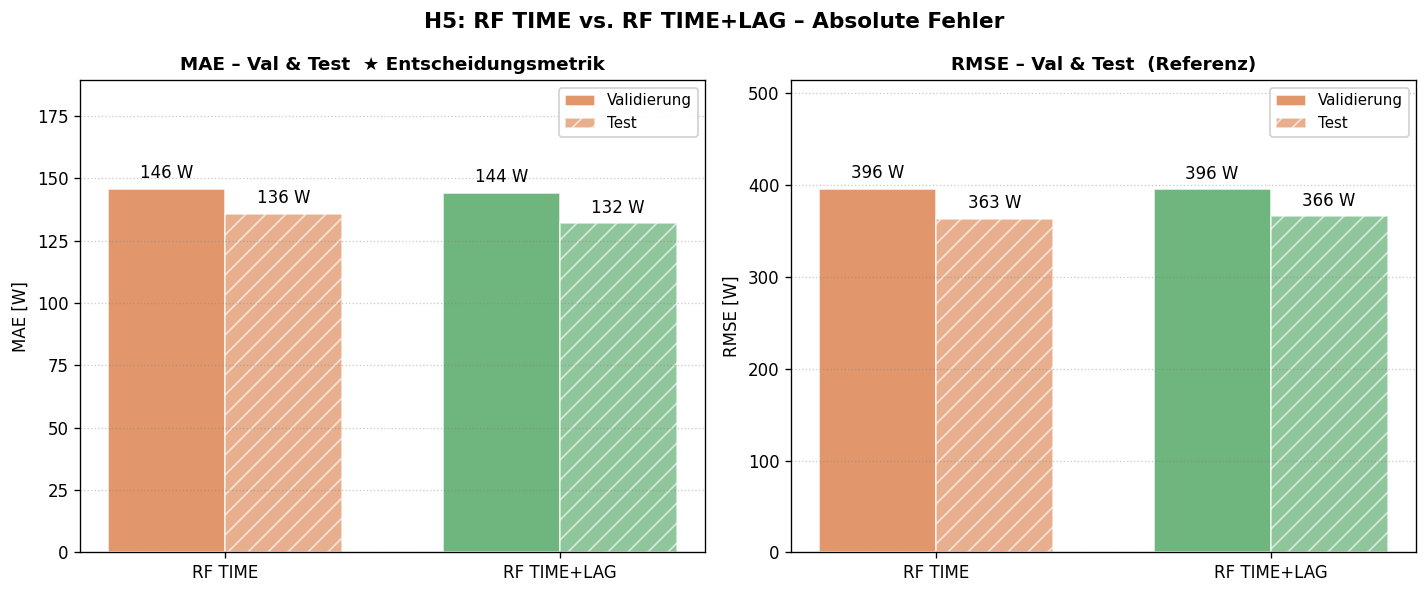

In [6]:
MODEL_DATA = {
    'RF TIME':     {'val': rf_time,   'test': rf_time_t},
    'RF TIME+LAG': {'val': rf_lag,    'test': rf_lag_t},
}

x     = np.arange(len(MODEL_ORDER))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(12, 5), facecolor='white')

for ax, metric_fn, title, ylabel in [
    (axes[0], mae_of,  'MAE – Val & Test  ★ Entscheidungsmetrik', 'MAE [W]'),
    (axes[1], rmse_of, 'RMSE – Val & Test  (Referenz)',            'RMSE [W]'),
]:
    ax.set_facecolor('white')
    for i, (split, hatch, label) in enumerate([('val', '', 'Validierung'), ('test', '//', 'Test')]):
        values = [metric_fn(MODEL_DATA[m][split]) for m in MODEL_ORDER]
        colors = [MODEL_COLORS[m] for m in MODEL_ORDER]
        offset = (i - 0.5) * width
        bars = ax.bar(x + offset, values, width, label=label,
                      color=colors, edgecolor='white', linewidth=1.0,
                      hatch=hatch, alpha=0.85 if split == 'val' else 0.65)
        ax.bar_label(bars, fmt='%.0f W', padding=4, fontsize=10)

    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.set_xticks(x)
    ax.set_xticklabels(MODEL_ORDER)
    ax.set_ylim(0, max(metric_fn(MODEL_DATA[m][s]) for m in MODEL_ORDER for s in ('val', 'test')) * 1.3)
    ax.legend(fontsize=9, framealpha=0.9)
    ax.grid(axis='y', linestyle=':', alpha=0.4, color='gray')

fig.suptitle('H5: RF TIME vs. RF TIME+LAG – Absolute Fehler', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.2 – ΔMAE & ΔRMSE durch Lag-Feature (TIME → TIME+LAG)

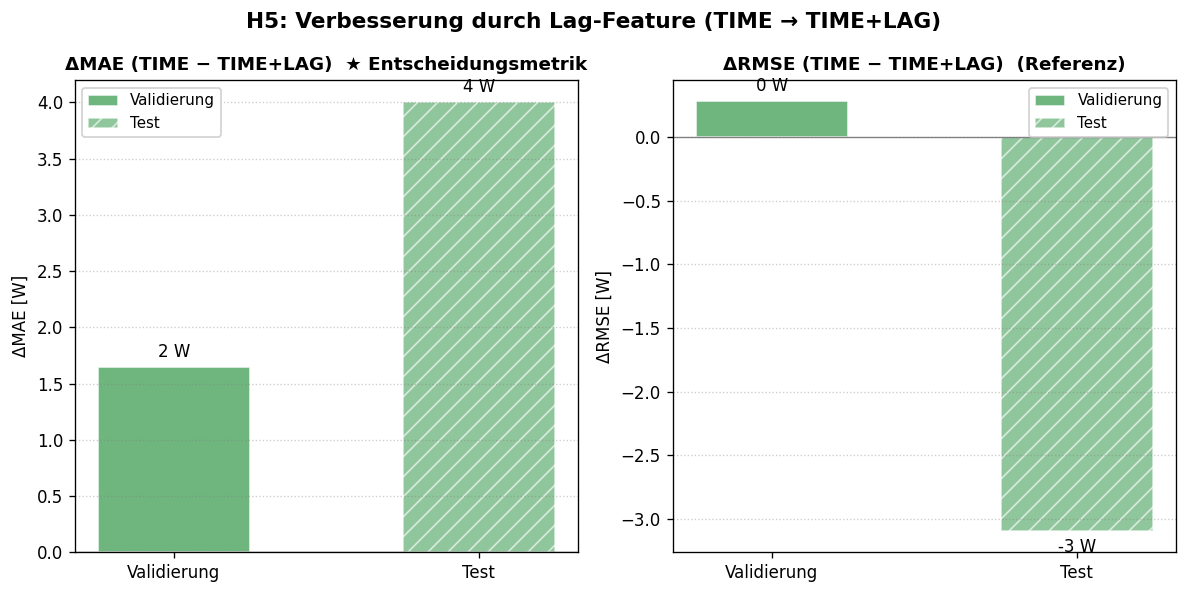

In [7]:
SPLITS = ['Validierung', 'Test']
delta_mae_vals  = [mae_of(rf_time)   - mae_of(rf_lag),   mae_of(rf_time_t)   - mae_of(rf_lag_t)]
delta_rmse_vals = [rmse_of(rf_time)  - rmse_of(rf_lag),  rmse_of(rf_time_t)  - rmse_of(rf_lag_t)]

x2 = np.arange(len(SPLITS))

fig, axes = plt.subplots(1, 2, figsize=(10, 5), facecolor='white')

for ax, deltas, title, ylabel in [
    (axes[0], delta_mae_vals,  'ΔMAE (TIME − TIME+LAG)  ★ Entscheidungsmetrik', 'ΔMAE [W]'),
    (axes[1], delta_rmse_vals, 'ΔRMSE (TIME − TIME+LAG)  (Referenz)',            'ΔRMSE [W]'),
]:
    ax.set_facecolor('white')
    colors = [MODEL_COLORS['RF TIME+LAG']] * len(SPLITS)
    hatches = ['', '//']
    for i, (val, hatch) in enumerate(zip(deltas, hatches)):
        bar = ax.bar(x2[i], val, 0.5, color=colors[i], edgecolor='white',
                     hatch=hatch, alpha=0.85 if i == 0 else 0.65,
                     label=SPLITS[i])
        ax.bar_label(bar, fmt='%.0f W', padding=4, fontsize=10)

    ax.axhline(0, color='gray', linewidth=0.8)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.set_xticks(x2)
    ax.set_xticklabels(SPLITS)
    ax.legend(fontsize=9, framealpha=0.9)
    ax.grid(axis='y', linestyle=':', alpha=0.4, color='gray')

fig.suptitle('H5: Verbesserung durch Lag-Feature (TIME → TIME+LAG)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.3 – Saisonale Aufschlüsselung (MAE je Jahreszeit)

,Split,Jahreszeit,RF TIME,RF TIME+LAG
0,Validierung,Winter,26.2,28.8
1,Validierung,Sommer,207.6,203.6
2,Validierung,Herbst,110.8,110.5
3,Test,Winter,91.5,88.9
4,Test,Frühling,164.4,159.1
5,Test,Sommer,181.5,178.3


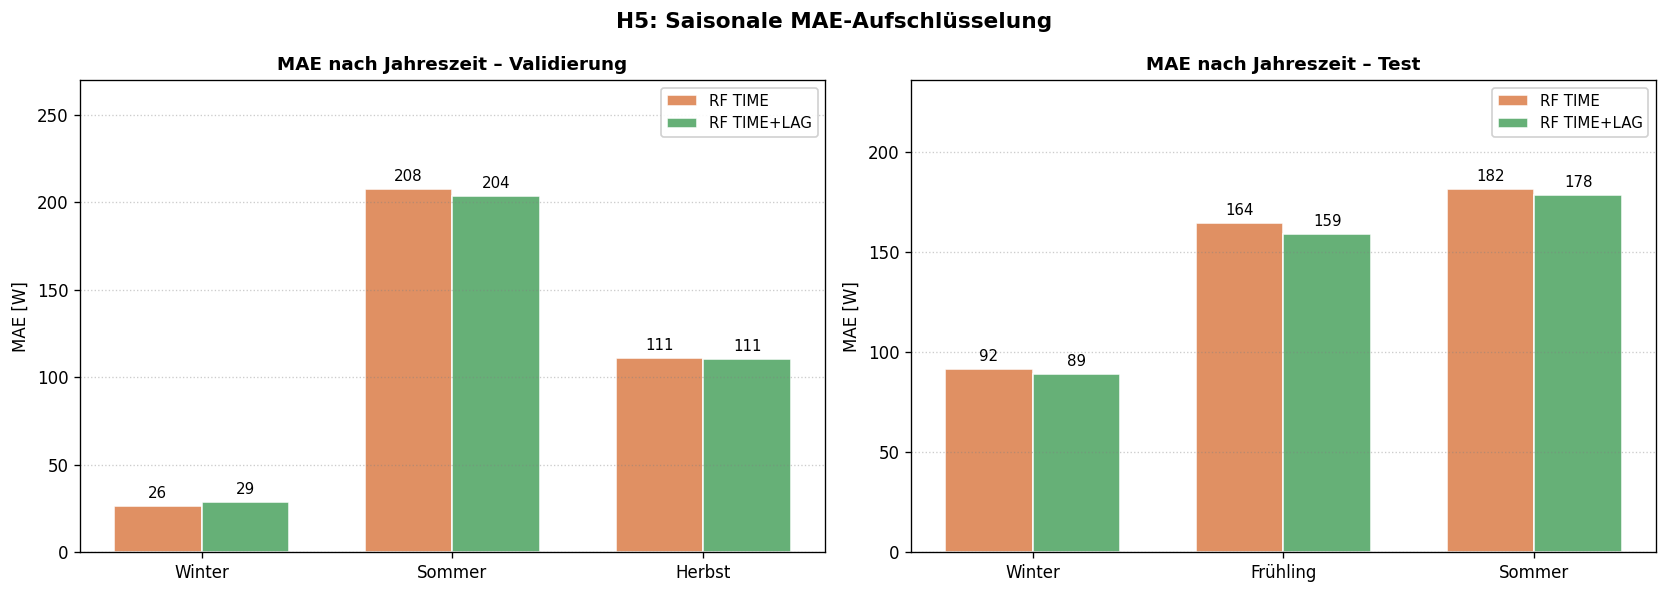

In [8]:
def season_mae(df):
    season = df.index.month.map(SEASON_MAP)
    return {s: (df[season == s]['y_true'] - df[season == s]['y_pred']).abs().mean()
            for s in SEASON_ORDER if (season == s).any()}

rows_season = []
for split_name, time_df, lag_df in [('Validierung', rf_time, rf_lag), ('Test', rf_time_t, rf_lag_t)]:
    for s in SEASON_ORDER:
        season_v = time_df.index.month.map(SEASON_MAP)
        season_l = lag_df.index.month.map(SEASON_MAP)
        t_sub = time_df[season_v == s]
        l_sub = lag_df[season_l == s]
        if t_sub.empty:
            continue
        rows_season.append({
            'Split': split_name, 'Jahreszeit': s,
            'RF TIME':     mae_of(t_sub),
            'RF TIME+LAG': mae_of(l_sub),
        })

season_df = pd.DataFrame(rows_season)
display(season_df.round(1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='white')

for ax, split_name in zip(axes, ['Validierung', 'Test']):
    sub = season_df[season_df['Split'] == split_name].set_index('Jahreszeit')
    sub = sub[MODEL_ORDER].reindex([s for s in SEASON_ORDER if s in sub.index])
    if sub.empty:
        ax.set_visible(False)
        continue

    ax.set_facecolor('white')
    x_s = np.arange(len(sub))
    for i, model in enumerate(MODEL_ORDER):
        offset = (i - 0.5) * 0.35
        bars = ax.bar(x_s + offset, sub[model], 0.35,
                      label=model, color=MODEL_COLORS[model],
                      edgecolor='white', alpha=0.9)
        ax.bar_label(bars, fmt='%.0f', padding=3, fontsize=9)

    ax.set_title(f'MAE nach Jahreszeit – {split_name}', fontsize=11, fontweight='bold')
    ax.set_ylabel('MAE [W]')
    ax.set_xticks(x_s)
    ax.set_xticklabels(sub.index)
    ax.set_ylim(0, sub.values.max() * 1.3)
    ax.legend(fontsize=9, framealpha=0.9)
    ax.grid(axis='y', linestyle=':', alpha=0.4, color='gray')

fig.suptitle('H5: Saisonale MAE-Aufschlüsselung', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.4 – Beispieltage je Jahreszeit (3 Tage, Val & Test)

Für jede verfügbare Jahreszeit werden 3 aufeinanderfolgende Tage gezeigt — Messwert, RF TIME und RF TIME+LAG im Vergleich.

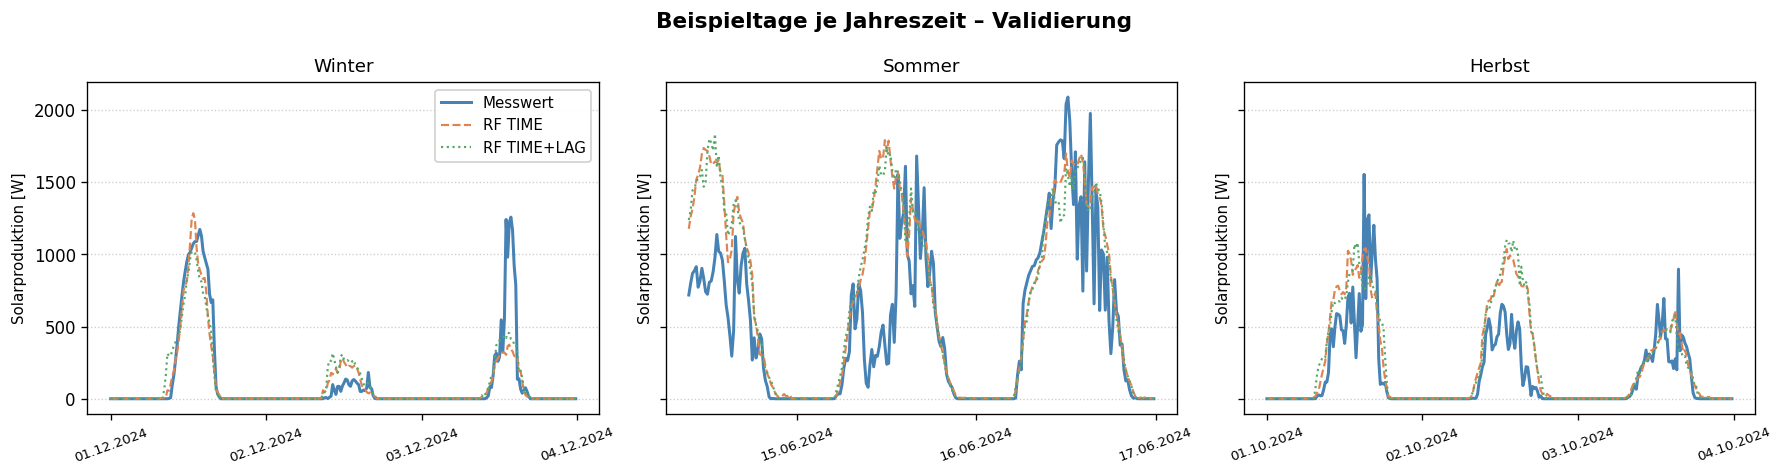

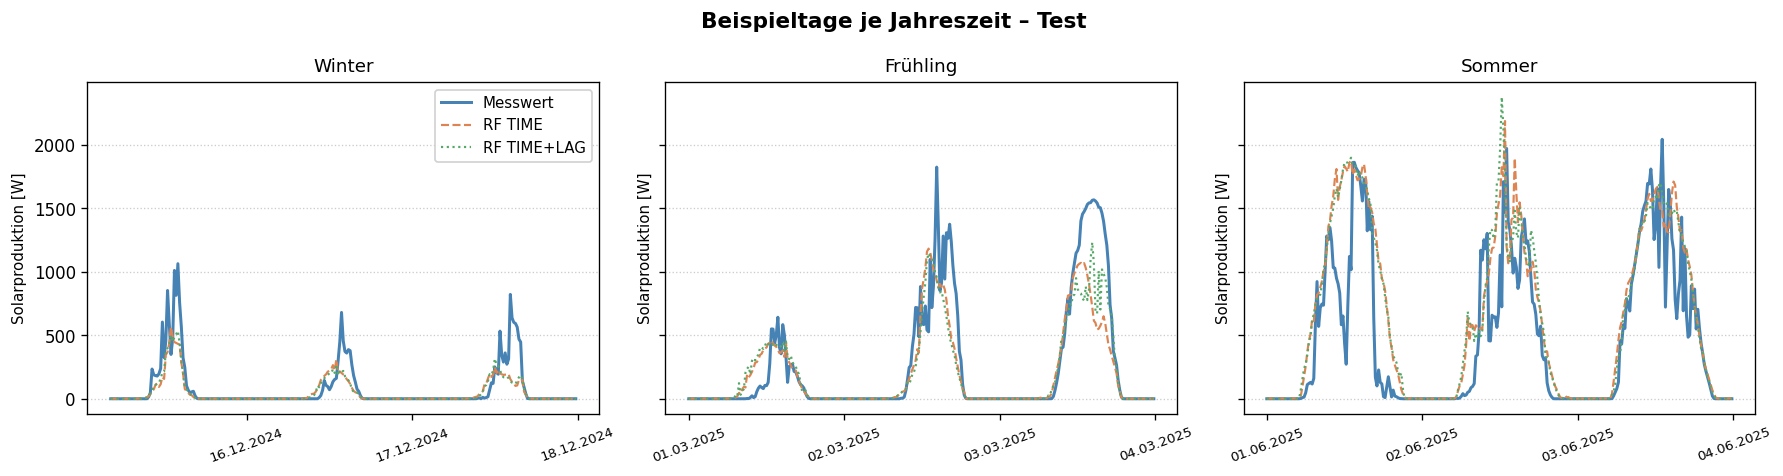

In [9]:
def add_season(df):
    out = df.copy()
    out['season'] = out.index.month.map(SEASON_MAP)
    return out

def pick_days(df, season_name, n_days=3, offset_days=0):
    sub = df[df['season'] == season_name].sort_index()
    if sub.empty:
        return None
    start = sub.index.min().floor('D') + pd.Timedelta(days=offset_days)
    end   = start + pd.Timedelta(days=n_days)
    window = sub[(sub.index >= start) & (sub.index < end)]
    return window if not window.empty else sub

SEASON_OFFSETS = {'Winter': 0, 'Frühling': 0, 'Sommer': 0, 'Herbst': 30}

# Val-Set: alle verfügbaren Jahreszeiten
rf_time_s = add_season(rf_time)
rf_lag_s  = add_season(rf_lag)
val_seasons = [s for s in SEASON_ORDER if (rf_time_s['season'] == s).any()]

fig, axes = plt.subplots(1, len(val_seasons), figsize=(5 * len(val_seasons), 4), sharey=True, facecolor='white')
if len(val_seasons) == 1:
    axes = [axes]
fig.suptitle('Beispieltage je Jahreszeit – Validierung', fontsize=13, fontweight='bold')

for ax, season_name in zip(axes, val_seasons):
    offset = SEASON_OFFSETS.get(season_name, 0)
    t_days = pick_days(rf_time_s, season_name, offset_days=offset)
    l_days = pick_days(rf_lag_s,  season_name, offset_days=offset)
    if t_days is None:
        ax.set_visible(False)
        continue

    ax.set_facecolor('white')
    ax.plot(t_days.index, t_days['y_true'],  label='Messwert',     color='steelblue', linewidth=1.8)
    ax.plot(t_days.index, t_days['y_pred'],  label='RF TIME',      color=MODEL_COLORS['RF TIME'],     linewidth=1.3, linestyle='--')
    ax.plot(l_days.index, l_days['y_pred'],  label='RF TIME+LAG',  color=MODEL_COLORS['RF TIME+LAG'], linewidth=1.3, linestyle=':')
    ax.set_title(f'{season_name}', fontsize=11)
    ax.set_ylabel('Solarproduktion [W]', fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d.%m.%Y'))
    ax.xaxis.set_major_locator(mdates.DayLocator())
    ax.tick_params(axis='x', rotation=20, labelsize=8)
    ax.grid(axis='y', linestyle=':', alpha=0.4, color='gray')

axes[0].legend(fontsize=9, framealpha=0.9)
plt.tight_layout()
plt.show()

# Test-Set
rf_time_st = add_season(rf_time_t)
rf_lag_st  = add_season(rf_lag_t)
test_seasons = [s for s in SEASON_ORDER if (rf_time_st['season'] == s).any()]

fig, axes = plt.subplots(1, len(test_seasons), figsize=(5 * len(test_seasons), 4), sharey=True, facecolor='white')
if len(test_seasons) == 1:
    axes = [axes]
fig.suptitle('Beispieltage je Jahreszeit – Test', fontsize=13, fontweight='bold')

for ax, season_name in zip(axes, test_seasons):
    offset = SEASON_OFFSETS.get(season_name, 0)
    t_days = pick_days(rf_time_st, season_name, offset_days=offset)
    l_days = pick_days(rf_lag_st,  season_name, offset_days=offset)
    if t_days is None:
        ax.set_visible(False)
        continue

    ax.set_facecolor('white')
    ax.plot(t_days.index, t_days['y_true'],  label='Messwert',     color='steelblue', linewidth=1.8)
    ax.plot(t_days.index, t_days['y_pred'],  label='RF TIME',      color=MODEL_COLORS['RF TIME'],     linewidth=1.3, linestyle='--')
    ax.plot(l_days.index, l_days['y_pred'],  label='RF TIME+LAG',  color=MODEL_COLORS['RF TIME+LAG'], linewidth=1.3, linestyle=':')
    ax.set_title(f'{season_name}', fontsize=11)
    ax.set_ylabel('Solarproduktion [W]', fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d.%m.%Y'))
    ax.xaxis.set_major_locator(mdates.DayLocator())
    ax.tick_params(axis='x', rotation=20, labelsize=8)
    ax.grid(axis='y', linestyle=':', alpha=0.4, color='gray')

axes[0].legend(fontsize=9, framealpha=0.9)
plt.tight_layout()
plt.show()

### 4.5 – Verteilung der Fehlerdifferenzen `d_t = |e_TIME| − |e_TIME+LAG|`

Positive Werte: TIME+LAG besser als TIME.

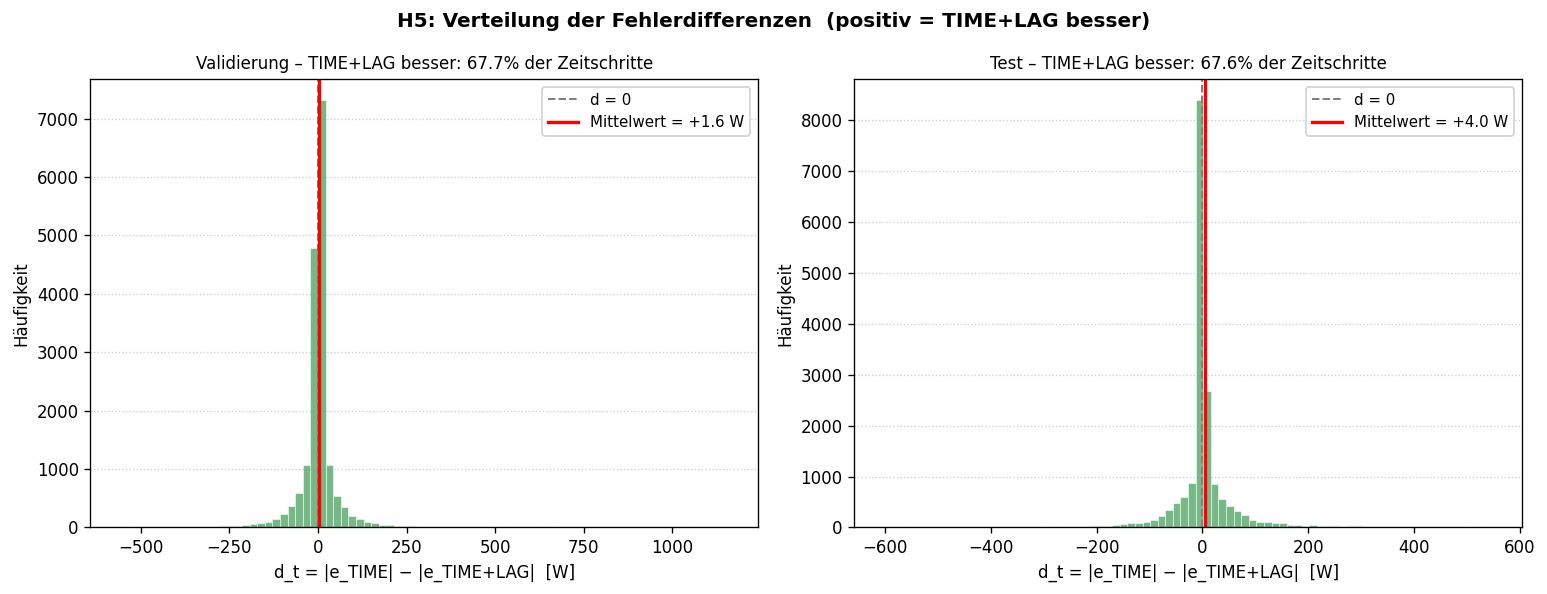

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor='white')

for ax, (split_label, d) in zip(axes, [
    ('Validierung', d_val),
    ('Test',        d_test),
]):
    ax.set_facecolor('white')
    d_clean = d.dropna()
    mean_d  = d_clean.mean()
    pct     = (d_clean > 0).mean() * 100

    ax.hist(d_clean, bins=80, color=MODEL_COLORS['RF TIME+LAG'],
            edgecolor='white', linewidth=0.4, alpha=0.8)
    ax.axvline(0,      color='gray', lw=1.2, ls='--', label='d = 0')
    ax.axvline(mean_d, color='red',  lw=2.0, ls='-',
               label=f'Mittelwert = {mean_d:+.1f} W')
    ax.set_title(f'{split_label} – TIME+LAG besser: {pct:.1f}% der Zeitschritte', fontsize=10)
    ax.set_xlabel('d_t = |e_TIME| − |e_TIME+LAG|  [W]')
    ax.set_ylabel('Häufigkeit')
    ax.legend(fontsize=9, framealpha=0.9)
    ax.grid(axis='y', linestyle=':', alpha=0.4, color='gray')

fig.suptitle('H5: Verteilung der Fehlerdifferenzen  (positiv = TIME+LAG besser)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 5 · Fazit

In [11]:
print("=" * 70)
print("FAZIT – H5: RF TIME vs. RF TIME+LAG")
print("=" * 70)

for split_name in ['Val', 'Test']:
    row       = ttest_df.loc[split_name]
    confirmed = row[f'H₁ (α={ALPHA})']
    delta_pct = (row['MAE TIME [W]'] - row['MAE LAG [W]']) / row['MAE TIME [W]'] * 100
    verdict   = 'BESTÄTIGT ✓' if confirmed else 'ABGELEHNT ✗'
    print(f"\n  {split_name}-Set")
    print(f"    MAE:  {row['MAE TIME [W]']:.1f} W → {row['MAE LAG [W]']:.1f} W  ({delta_pct:+.1f}%)")
    print(f"    mean(d_t) = {row['ΔMAE [W]']:+.1f} W   p = {row['p-Wert (1-s.)']:.4f}   → H₁ {verdict}")

print()
print("-" * 70)
print("""
Interpretation:
  Das Lag-Feature (Solarproduktion_lag_96, 24h-Rückblick) liefert dem
  Random Forest einen direkten Hinweis auf die gestrige Produktion des
  gleichen 15-min-Slots — ein starkes Signal bei stabilen Wetterlagen.

  Die Verbesserung ist auf dem Val-Set tendenziell geringer als auf dem
  Test-Set, da das Val-Set Sommer/Herbst enthält (stärkere Variabilität)
  während das Test-Set Winter/Frühling umfasst (stabilere Muster).
""")
print("=" * 70)

FAZIT – H5: RF TIME vs. RF TIME+LAG

  Val-Set
    MAE:  145.7 W → 144.0 W  (+1.1%)
    mean(d_t) = +1.6 W   p = 0.0007   → H₁ BESTÄTIGT ✓

  Test-Set
    MAE:  135.8 W → 131.8 W  (+2.9%)
    mean(d_t) = +4.0 W   p = 0.0000   → H₁ BESTÄTIGT ✓

----------------------------------------------------------------------

Interpretation:
  Das Lag-Feature (Solarproduktion_lag_96, 24h-Rückblick) liefert dem
  Random Forest einen direkten Hinweis auf die gestrige Produktion des
  gleichen 15-min-Slots — ein starkes Signal bei stabilen Wetterlagen.

  Die Verbesserung ist auf dem Val-Set tendenziell geringer als auf dem
  Test-Set, da das Val-Set Sommer/Herbst enthält (stärkere Variabilität)
  während das Test-Set Winter/Frühling umfasst (stabilere Muster).

